# Using Gambit with SageMath: strategic form games

[SageMath](https://www.sagemath.org/) is a general-purpose open-source mathematics system built on top of Python.
Its `sage.game_theory` module includes a `NormalFormGame` class, which integrates Gambit solvers.

This tutorial shows how a game can be created and analyzed by the two libraries, walks through each part of the interface, and finishes with two case studies that use SageMath to do things Gambit cannot do on its own: solving a game whose payoffs are *symbols* rather than numbers, and building a game out of a combinatorial object.

The clear benefit of using both libraries is their combined expertise:

- **Gambit** knows how to compute equilibria. Its solvers are fast, numerous, and established.
- **SageMath** knows how to do mathematics *around* the game: exact rational and symbolic algebra, graphs and other combinatorial structures, plotting, and calculus.

> **Requirements.** This tutorial uses the SageMath interface introduced in [sagemath/sage#42367](https://github.com/sagemath/sage/pull/42367), which at the time of writing has not yet been released.
> You will need a SageMath build containing that work, plus the optional `pygambit` package (`sage --pip install pygambit`).
> Run the notebook with the **SageMath kernel**, not a plain Python kernel: the examples below rely on Sage's preparser, which makes `1/3` an exact rational rather than a floating point number.

In [1]:
import itertools

import numpy as np
from sage.version import version

import pygambit as gbt

print("SageMath", version, "| pygambit", gbt.__version__)

SageMath 10.10.beta8 | pygambit 16.7.0


## From a Gambit game to a Sage game

We start on the Gambit side, with the Prisoner's Dilemma built from a pair of payoff arrays.

In [2]:
pd_gambit = gbt.Game.from_arrays(
    np.array([[3, 0], [5, 1]]),
    np.array([[3, 5], [0, 1]]),
    title="Prisoner's Dilemma",
)
pd_gambit

Game(title='Prisoner's Dilemma')

Passing that `Game` straight to `NormalFormGame` converts it.
A Sage normal form game is a mapping from strategy profiles (tuples of integers) to lists of payoffs, so this is what we get back:

In [3]:
pd = NormalFormGame(pd_gambit)
pd

Normal Form Game with the following utilities: {(0, 0): [3, 3], (0, 1): [0, 5], (1, 0): [5, 0], (1, 1): [1, 1]}

Gambit stores payoffs either as exact rationals or as decimals, and Sage keeps this distinction. The integer payoffs above came back as elements of `QQ`, which is the field of rational numbers, and *not* as floating point approximations.

In [4]:
parent(pd.utilities[(0, 0)][0])

Rational Field

That matters for all downstream applications. `payoff_matrices` returns the two payoff matrices as Sage matrices over `QQ`, which we can then do linear algebra on.

In [5]:
A, B = pd.payoff_matrices()
A, B, A.base_ring()

(
[3 0]  [3 5]                
[5 1], [0 1], Rational Field
)

## From a Sage game to a Gambit game

The other direction is the `_gambit_` method, which every Sage `NormalFormGame` provides.
It returns a `pygambit.Game`, so the whole Gambit API is available from there, including writing the game out in Gambit's own strategic form format.
To test this out, we will load the Prisoner's Dilemma directly from the SageMath strategic game catalog.

In [6]:
pd = game_theory.normal_form_games.PrisonersDilemma()
print(pd._gambit_().to_nfg())

NFG 1 R "Untitled strategic game" { "1" "2" }

{ { "1" "2" }
{ "1" "2" }
}
""

{
{ "" -2, -2 }
{ "" 0, -5 }
{ "" -5, 0 }
{ "" -4, -4 }
}
1 2 3 4 



Payoffs are handed to Gambit one at a time, and each keeps the kind of value it is: an exact Sage integer or rational becomes a Gambit `Rational`, an inexact real becomes a Gambit `Decimal`. Nothing is rounded or truncated on the way.

In [7]:
exact = NormalFormGame([matrix(QQ, [[1/3, 2], [1, 5/7]])])._gambit_()
exact["1", "1"][exact.players["1"]]

Rational(1, 3)

`_gambit_` takes one option. `maximization=False` negates every payoff, so a game written down in terms of *costs* is handed to Gambit as a game to be maximised.

In [8]:
g_max = pd._gambit_()
g_min = pd._gambit_(maximization=False)

[QQ(g_max["1", "1"][g_max.players["1"]]),
 QQ(g_min["1", "1"][g_min.players["1"]])]

[-2, 2]

## Saving and loading games

Because the conversion goes through Gambit, Sage can read and write Gambit's `.nfg` files directly.
This is the simplest way to move a game between a Sage session and the Gambit GUI, or to keep a game under version control.

`save_nfg` writes the game the object holds, so it is an ordinary method. `load_nfg` builds a *new* game from a file, so it is a class method: call it on the class and it hands you the game back.

In [9]:
path = tmp_filename(ext=".nfg")
pd.save_nfg(path)

reloaded = NormalFormGame.load_nfg(path)
reloaded

Normal Form Game with the following utilities: {(0, 0): [-2, -2], (0, 1): [-5, 0], (1, 0): [0, -5], (1, 1): [-4, -4]}

The round trip is exact. Gambit's `.nfg` format records a rational payoff as a fraction rather than a decimal, so a game of exact payoffs survives a trip through the disk unchanged.

In [10]:
fractions = NormalFormGame([matrix(QQ, [[1/3, 2], [1, 5/7]])])
path = tmp_filename(ext=".nfg")
fractions.save_nfg(path)

back = NormalFormGame.load_nfg(path)
back.utilities[(0, 0)][0], parent(back.utilities[(0, 0)][0])

(1/3, Rational Field)

## The Gambit game catalog

As SageMath's catalog of normal form games consists of mostly simpler, common games, we extend it by Gambit's catalog. It allows Sage to access a variety of games from the research literature.

Listing and loading are two separate class methods. `gambit_catalog_games` returns a table of what is available.

In [11]:
NormalFormGame.gambit_catalog_games()

,Game,Title
0,books/myerson1991/fig2_1,A simple Poker game
1,books/myerson1991/fig4_2,Myerson (1991) Figure 4.2
2,books/shohamleytonbrown2008/fig5_1,Fig 5.1 from Shoham and Leyton-Brown (2008)
3,books/shohamleytonbrown2008/fig5_10,Fig 5.10 from Shoham and Leyton-Brown (2008)
4,books/shohamleytonbrown2008/fig5_11,Fig 5.11 from Shoham and Leyton-Brown (2008)
5,books/shohamleytonbrown2008/fig5_12,Fig 5.12 from Shoham and Leyton-Brown (2008)
6,books/shohamleytonbrown2008/fig5_15,Fig 5.15 from Shoham and Leyton-Brown (2008)
7,books/shohamleytonbrown2008/fig5_2,Fig 5.2 from Shoham and Leyton-Brown (2008)
8,books/shohamleytonbrown2008/fig5_9,Fig 5.9 from Shoham and Leyton-Brown (2008)
9,books/shohamleytonbrown2008/fig6_2,Fig 6.2 from Shoham and Leyton-Brown (2008)


Its keyword arguments are passed on to Gambit's own catalog listing, so the table can be filtered — by the number of players, for instance.

In [12]:
NormalFormGame.gambit_catalog_games(n_players=3)

,Game,Title
0,journals/ijgt/nau2004/sec4,Three-player game with a unique Nash solution ...
1,journals/ijgt/nau2004/sec5,Game with a continuum of completely mixed-stra...
2,journals/ijgt/nau2004/sec6,2x2x4 game with Nash equilibria in the relativ...
3,journals/ijgt/selten1975/fig1,"Selten's horse (Selten IJGT 1975, Figure 1)"
4,journals/ijgt/selten1975/fig3,Selten (IJGT 1975) Figure 3


`load_from_gambit_catalog` takes a slug from the `Game` column and returns the game.
Here is Bagwell's game on commitment and observability:

In [13]:
NormalFormGame.load_from_gambit_catalog("journals/geb/bagwell1995")

Normal Form Game with the following utilities: {(0, 0): [5, 2],
 (0, 1): [249/50, 199/100],
 (0, 2): [151/50, 101/100],
 (0, 3): [3, 1],
 (1, 0): [6, 3],
 (1, 1): [201/50, 399/100],
 (1, 2): [299/50, 301/100],
 (1, 3): [4, 4]}

That one is a tree game in Gambit's catalog, and a `NormalFormGame` is always a strategic form game, so it arrives as its reduced strategic form: each player's strategies are complete contingent plans rather than single moves. The companion tutorial loads the same game as a tree.

## Solving games

`obtain_nash` is Sage's entry point to equilibrium computation.
Without a passed parameter of which algorithm to use, it picks a sensible default; with the specification of algorithm, it dispatches either to Sage's own exact routines or to one of Gambit's solvers.

Our test case is the Battle of the Sexes, which has two pure equilibria and one mixed one.

In [14]:
battle = NormalFormGame([matrix([[3, 1], [0, 2]]),
                         matrix([[2, 1], [0, 3]])])
battle.obtain_nash()

[[(0, 1), (0, 1)], [(3/4, 1/4), (1/4, 3/4)], [(1, 0), (1, 0)]]

The answer is *exact*: the mixed equilibrium comes out as `3/4` and `1/4`, not as decimals.

That holds whichever solver computes it. `'enumeration'` stays in Sage, while `'LCP'` and `'enummixed'` are Gambit's, and all three agree exactly.
(Sage also offers `'lrs'`, which uses the external `lrslib` package; it is not installed here, so it is left out of the comparison below.)

In [15]:
for algorithm in ["enumeration", "LCP", "enummixed"]:
    print(f"{algorithm:12s}", battle.obtain_nash(algorithm=algorithm))

enumeration  [[(0, 1), (0, 1)], [(3/4, 1/4), (1/4, 3/4)], [(1, 0), (1, 0)]]
LCP          [[(0, 1), (0, 1)], [(3/4, 1/4), (1/4, 3/4)], [(1, 0), (1, 0)]]
enummixed    [[(0, 1), (0, 1)], [(3/4, 1/4), (1/4, 3/4)], [(1, 0), (1, 0)]]


This is what the `rational` argument of `obtain_nash` does, and it defaults to `True`. Sage asks the solvers that have an exact mode — `'LCP'`, `'lp'` and `'enummixed'` — to compute in exact arithmetic throughout. The purely numerical ones (`'gnm'`, `'ipa'`, `'logit'`, `'liap'`, `'enumpoly'`) have no exact mode, so they compute in floating point and Sage then rounds the answer to the exact equilibrium it approximates, keeping the rounding only once Gambit has confirmed in exact arithmetic that it really is one. How far a probability may be moved to be rounded is set by `tolerance`.

Passing `rational=False` skips all of that and returns what the solver computed.

In [16]:
battle.obtain_nash(algorithm="LCP", rational=False)

[[(0.0, 1.0), (0.0, 1.0)],
 [(0.7499999999999999, 0.25), (0.24999999999999994, 0.7500000000000001)],
 [(1.0, 0.0), (1.0, 0.0)]]

So exactness is no longer the thing that separates the two libraries: use Sage's solvers when you want its own exact routines on a small game, and Gambit's when the game is large enough that they become the bottleneck.

Sage can also tell you whether the game is degenerate, which is worth checking before trusting an equilibrium count, and whether it is constant sum.

In [17]:
battle.is_degenerate(), battle.is_constant_sum()

(False, False)

## Games with more than two players

A two player game is a pair of matrices, but a game with $n$ players needs $n$ payoff arrays of $n$ dimensions each, and a Sage matrix is only ever two dimensional.
For more than two players, pass NumPy arrays instead.

Here is a three player consensus game: everybody picks one of two options, and everybody scores a point only if all three agree.

In [18]:
agree = np.zeros((2, 2, 2), dtype=int)
agree[0, 0, 0] = 1
agree[1, 1, 1] = 1

consensus = NormalFormGame([agree, agree, agree])
consensus.obtain_nash(algorithm="enumpure")

[[(0, 1), (0, 1), (0, 1)], [(1, 0), (1, 0), (1, 0)]]

Both "everyone picks the first option" and "everyone picks the second" are equilibria, as expected.

Since Sage's own solvers only handle two players, every algorithm for larger games comes from the Gambit solver integration. These are: `'gnm'`, `'enumpure'`, `'enumpoly'`, `'liap'`, `'simpdiv'`, `'ipa'` and `'logit'`.
The default for a game with more than two players is `'enumpoly'`, which finds the mixed equilibrium too.

In [19]:
consensus.obtain_nash()

[[(0, 1), (0, 1), (0, 1)],
 [(1/2, 1/2), (1/2, 1/2), (1/2, 1/2)],
 [(1, 0), (1, 0), (1, 0)]]

`'enumpoly'` is one of the solvers with no exact mode, so the `1/2` above is a rounded answer that Gambit then verified. A game of three or more players can have a genuinely irrational equilibrium, and there the rounding fails and the floating point answer is returned instead.

## Plotting a game

Sage can draw a two player game as a labelled payoff bimatrix, optionally marking each player's best responses and the pure equilibria.

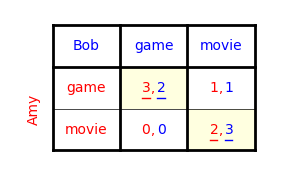

In [20]:
battle.plot(player_labels=["Amy", "Bob"],
            strategy_labels=[["game", "movie"], ["game", "movie"]],
            best_responses=True, pure_nash=True)

## Case study 1: a game whose payoffs are symbols

Everything so far could be described as file conversion. This is where the integration starts to pay for itself.

Gambit's solvers work on numbers. Sage's symbolic ring works on *expressions*, and a `NormalFormGame` is perfectly happy to hold them. So we can write down a whole family of games at once and solve it in closed form.

The example is Hawk–Dove. Two animals contest a resource worth $v$. Two doves split it; a hawk takes it from a dove; two hawks fight and share the value minus a cost $c$ of injury.

In [21]:
v, c, p = var("v c p")

H = matrix([[(v - c)/2, v],
            [0,         v/2]])
hawk_dove = NormalFormGame([H, H.transpose()])
hawk_dove

Normal Form Game with the following utilities: {(0, 0): [-1/2*c + 1/2*v, -1/2*c + 1/2*v],
 (0, 1): [v, 0],
 (1, 0): [0, v],
 (1, 1): [1/2*v, 1/2*v]}

In the mixed equilibrium each animal plays Hawk with some probability $p$ that leaves its opponent indifferent between the two behaviours.
We write that indifference condition down and ask Sage to solve it.

In [22]:
hawk = p*(v - c)/2 + (1 - p)*v
dove = (1 - p)*v/2

solution = solve(hawk == dove, p)
solution

[p == v/c]

The equilibrium share of hawks is $p^* = v/c$ — a closed form valid for every $v$ and $c$ at once, which no numerical solver could have produced.
Being an ordinary Sage expression, we can now plot it, differentiate it, or take limits of it.

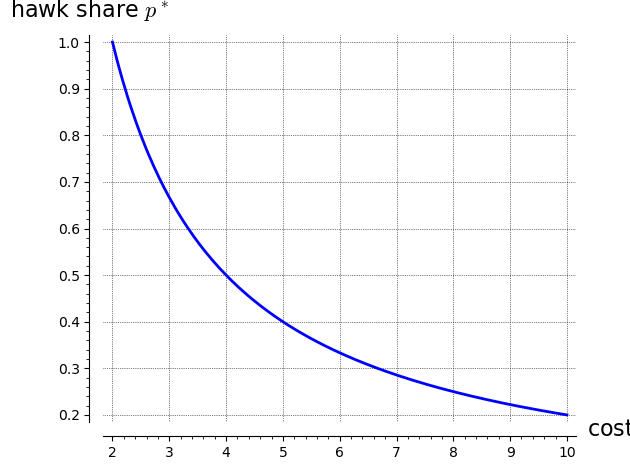

In [23]:
p_star = solution[0].rhs()

plot(p_star.subs(v=2), (c, 2, 10), axes_labels=["cost $c$", "hawk share $p^*$"],
     thickness=2, gridlines=True)

And we can check the formula against Gambit.
Substituting $v = 2$, $c = 5$ turns the symbolic matrices into numeric ones, at which point the game converts and Gambit's `enummixed` solver applies.

In [24]:
numeric = NormalFormGame([H.subs(v=2, c=5),
                          H.transpose().subs(v=2, c=5)])
numeric.obtain_nash(algorithm="enummixed")

[[(0, 1), (1, 0)], [(2/5, 3/5), (2/5, 3/5)], [(1, 0), (0, 1)]]

The middle equilibrium puts weight `2/5` on Hawk, and the formula gives the same value exactly. The two answers can be compared directly rather than up to a floating point tolerance.

In [25]:
p_hat = numeric.obtain_nash(algorithm="enummixed")[1][0][0]

QQ(p_star.subs(v=2, c=5)) == p_hat

True

## Case study 2: from a graph to a game

The second thing Sage brings is its library of mathematical objects. Here we turn a *graph* into a game and let Gambit analyse it.

In the **max cut game**, every vertex of a graph is a player choosing one of two sides. A player's payoff is the number of its incident edges that end up cut, that is, joining vertices on opposite sides. A pure Nash equilibrium is exactly a cut that no single vertex can improve by switching sides — a *locally* optimal cut.

We use the house graph: five vertices, six edges.

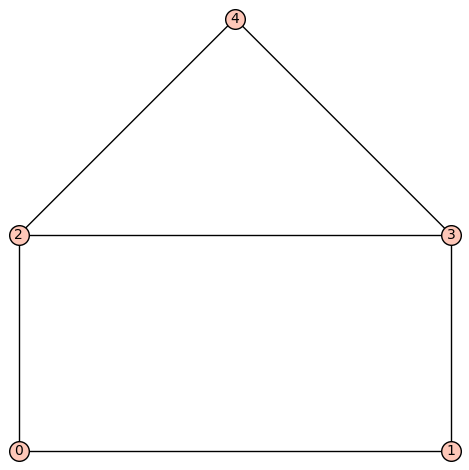

In [26]:
G = graphs.HouseGraph()
G.plot(vertex_labels=True)

Building the game is a matter of filling in one payoff array per vertex.
Sage's graph API supplies the vertices and the neighbours, and NumPy holds the payoffs.

In [27]:
def max_cut_game(graph):
    """Return the max cut game of ``graph`` as a Sage ``NormalFormGame``."""
    vertices = sorted(graph.vertices())
    arrays = [np.zeros((2,) * len(vertices), dtype=int) for _ in vertices]
    for profile in itertools.product([0, 1], repeat=len(vertices)):
        side = dict(zip(vertices, profile, strict=True))
        for i, u in enumerate(vertices):
            arrays[i][profile] = sum(1 for w in graph.neighbors(u)
                                     if side[w] != side[u])
    return NormalFormGame(arrays)


game = max_cut_game(G)
len(game.players)

5

Five players, so this is squarely in Gambit's territory. `'enumpure'` enumerates the pure equilibria.

In [28]:
equilibria = game.obtain_nash(algorithm="enumpure")
len(equilibria)

6

Each equilibrium is a cut, so we read the profiles back and count how many edges each one cuts.
The probabilities are exact, so a pure strategy is the integer `0` or `1` and needs no rounding.

In [29]:
def cut_size(profile):
    return sum(1 for (u, w) in G.edges(labels=False) if profile[u] != profile[w])


profiles = sorted({tuple(int(s[1]) for s in eq) for eq in equilibria})
for profile in profiles:
    print(f"{profile}  cuts {cut_size(profile)} edges")

(0, 0, 1, 1, 0)  cuts 4 edges
(0, 1, 1, 0, 0)  cuts 5 edges
(0, 1, 1, 0, 1)  cuts 5 edges
(1, 0, 0, 1, 0)  cuts 5 edges
(1, 0, 0, 1, 1)  cuts 5 edges
(1, 1, 0, 0, 1)  cuts 4 edges


In [30]:
G.max_cut(value_only=True)

5

Four of the six equilibria achieve the optimum of five cut edges, but two of them get stuck at four.
Those are the locally stable cuts that are not globally optimal, and the ratio $4/5$ is this game's price of anarchy.

Gambit found the equilibria; Sage certified which of them were actually good. Neither library could have produced that sentence alone.

## Summary

| Task | Call |
|---|---|
| Gambit game to Sage | `NormalFormGame(game)` |
| Sage game to Gambit | `game._gambit_()` |
| Read and write `.nfg` | `NormalFormGame.load_nfg(path)`, `game.save_nfg(path)` |
| Browse the Gambit catalog | `NormalFormGame.gambit_catalog_games()` |
| Load a catalog game | `NormalFormGame.load_from_gambit_catalog(slug)` |
| Solve with Sage (exact, two players) | `game.obtain_nash(algorithm='enumeration')` |
| Solve with Gambit | `game.obtain_nash(algorithm='LCP')` and friends |
| Solve with more than two players | `game.obtain_nash(algorithm='enumpoly')` |
| Ask for floating point answers | `game.obtain_nash(rational=False)` |
| Draw the payoff bimatrix | `game.plot()` |

For games in extensive form — trees, information sets, and chance moves — see the companion tutorial, [Using Gambit with SageMath: extensive form games](sagemath_extensive_form.ipynb).

Further reading:

- [SageMath game theory reference](https://doc.sagemath.org/html/en/reference/game_theory/index.html)
- [PyGambit API documentation](https://gambitproject.readthedocs.io/en/latest/pygambit.api.html)